# Semantic abstraction graphicalizer

Thin experiment notebook: configure the run, invoke the package, and visualize the resulting graph, sample a connected subgraph, and narrate it.

In [18]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import textwrap

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'assets').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'assets').exists():
    raise FileNotFoundError('Could not locate the repository assets directory.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from graphicalizer import (
    ExtractionDensityConfig,
    Graphicalizer,
    GraphicalizerConfig,
    NodeContextConfig,
    SubgraphNarrator,
    SubgraphNarrativeConfig,
    SubgraphNarrativePrompt,
    sample_random_connected_subgraph,
    graph_to_dot,
    load_ontology,
    load_text,
    render_graph,
    validate_ontology_labeled_graph,
)
from IPython.display import SVG, display

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configure and run

In [19]:
ASSETS_ROOT = PROJECT_ROOT / 'assets'
PUBMED_ABSTRACT_INDEX = 2  # zero-based: 0 selects the first abstract
PUBMED_ABSTRACT_PATHS = sorted((ASSETS_ROOT / 'abstracts' / 'pubmed').glob('*.txt'))
if not PUBMED_ABSTRACT_PATHS:
    raise FileNotFoundError('No PubMed abstracts found.')
if not 0 <= PUBMED_ABSTRACT_INDEX < len(PUBMED_ABSTRACT_PATHS):
    raise IndexError(
        f'PUBMED_ABSTRACT_INDEX must be between 0 and {len(PUBMED_ABSTRACT_PATHS) - 1}.'
    )
ABSTRACT_PATH = PUBMED_ABSTRACT_PATHS[PUBMED_ABSTRACT_INDEX]
ONTOLOGY_PATH = ASSETS_ROOT / 'ontologies' / 'entity_ontology_microbiology.yaml'
PROMPT_PATH = ASSETS_ROOT / 'prompts' / 'graphicalizer_prompt_template.yaml'
PROMPT_SNAPSHOT_PATH = PROJECT_ROOT / 'outputs' / 'prompts' / 'ontology-aware-graphicalizer-0.4.0.yaml'
GRAPH_OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'nipah_ontology_graph.svg'
LLM_PROVIDER = 'openai'  # choose 'openai' or 'ollama'
LLM_MODEL = 'gpt-4o-mini' if LLM_PROVIDER == 'openai' else 'gemma4:12b-mlx' # 'gpt-4o-mini' 'gpt-5-nano'
LLM_OPTIONS = (
    {'max_output_tokens': 16384}
    if LLM_PROVIDER == 'openai'
    else {'num_ctx': 32768, 'num_predict': -1}
)
NARRATIVE_COLUMNS = 80

abstract_text = load_text(ABSTRACT_PATH)
print(textwrap.fill(abstract_text, width=NARRATIVE_COLUMNS))

ontology = load_ontology(ONTOLOGY_PATH)
ENTITY_EFFORT = 0.2
RELATION_EFFORT = 1.5
density = ExtractionDensityConfig(
    entities_per_word=ENTITY_EFFORT,
    relations_per_entity=RELATION_EFFORT,
)
context = NodeContextConfig(
    max_sentences=3,
    max_evidence_items=2,
    include_evidence=True,
    include_uncertainty=True,
)
config = GraphicalizerConfig(
    provider=LLM_PROVIDER,
    model=LLM_MODEL,
    extraction_density=density,
    node_context=context,
    prompt_template_path=PROMPT_PATH,
    prompt_snapshot_path=PROMPT_SNAPSHOT_PATH,
    disconnected_policy='largest_component',
    context_policy='all_nodes',
    casting_retries=2,
)

graphicalizer = Graphicalizer.from_provider(ontology, config, options=LLM_OPTIONS)
result = graphicalizer.run(abstract_text)

Title: Transmission of henipaviruses. PMID: 29035743 Journal: Current opinion in
virology Publication date: 2018Feb DOI: 10.1016/j.coviro.2017.09.004 Authors:
Sarah Weatherman, Heinz Feldmann, Emmie de Wit  Abstract: The genus Henipavirus
has expanded rapidly in geographic range, number of species, and host range.
Hendra and Nipah virus are two henipaviruses known to cause severe disease in
humans with a high case-fatality rate. Pteropid spp. bats are the natural
reservoir of Hendra and Nipah virus. From these bats, virus can be transmitted
to an amplifying host, horses and pigs, and from these hosts to humans, or the
virus can be transmitted directly to humans. Although the main route of shedding
varies between host species, close contact is required for transmission in all
hosts. Understanding the transmission routes of Hendra and Nipah virus in their
respective hosts is essential for devising strategies to block zoonotic
transmission.


In [20]:
print('Model:', config.model)
print('Source SHA-256:', result.run_metadata['source_sha256'])
print('Raw validation:', result.raw_validation.to_dict())
print('Normalized validation:', result.normalized_validation.to_dict())
print('Normalization report:', result.normalization_report)
print('Final validation:', result.final_validation.to_dict())
print('Entities:', len(result.normalized_extraction.entities))
print('Relations:', len(result.ontology_casting.relations))
print('Node contexts:', len(result.node_contexts))

Model: gpt-4o-mini
Source SHA-256: 1fe45cc8e9db50b06942d7e8e2078e3ba3bbf68631d703e6958ba3f3d9973b84
Raw validation: {'valid': False, 'connected': True, 'sparse': False, 'node_count': 7, 'edge_count': 10, 'density': 0.47619047619047616, 'max_neighbor_count': 6, 'hub_nodes': ('e7',), 'issues': ('graph density 0.476 exceeds 0.400', 'graph contains 1 hub node(s): e7'), 'density_ok': False, 'hubs_ok': False}
Normalized validation: {'valid': False, 'connected': True, 'sparse': False, 'node_count': 7, 'edge_count': 10, 'density': 0.47619047619047616, 'max_neighbor_count': 6, 'hub_nodes': ('e7',), 'issues': ('graph density 0.476 exceeds 0.400', 'graph contains 1 hub node(s): e7'), 'density_ok': False, 'hubs_ok': False}
Normalization report: {'policy': 'largest_component', 'component_count': 1, 'retained_entity_ids': ('e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e7'), 'discarded_entity_ids': (), 'retained_relation_ids': ('r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10'), 'discarded_relation_

## Visualize the typed graph

digraph "NipahVirusZoonoticGraph" {
  rankdir=LR;
  "e1" [label="virus\nHenipavirus", shape=box];
  "e2" [label="pathogen\nHendra virus", shape=box];
  "e3" [label="pathogen\nNipah virus", shape=box];
  "e4" [label="reservoir_host\nPteropid bats", shape=box];
  "e5" [label="animal_host\nhorses", shape=box];
  "e6" [label="animal_host\npigs", shape=box];
  "e7" [label="human_host\nhumans", shape=box];
  "e1" -> "e2" [color="#555555", label="subtype_of"];
  "e1" -> "e3" [color="#555555", label="subtype_of"];
  "e1" -> "e7" [color="#555555", label="spills_over_from"];
  "e2" -> "e7" [color="#555555", label="infects"];
  "e3" -> "e7" [color="#555555", label="infects"];
  "e4" -> "e2" [color="#555555", label="maintained_in"];
  "e4" -> "e3" [color="#555555", label="maintained_in"];
  "e4" -> "e7" [color="#555555", label="spills_over_from"];
  "e5" -> "e7" [color="#555555", label="transmitted_to"];
  "e6" -> "e7" [color="#555555", label="transmitted_to"];
}



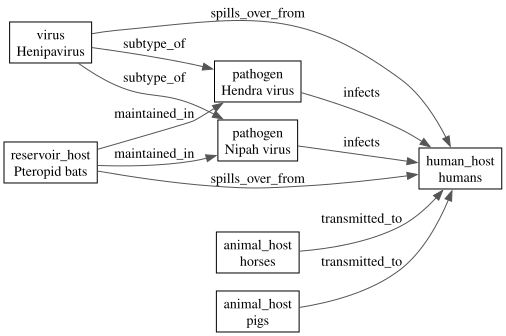

In [21]:
validate_ontology_labeled_graph(result.typed_graph)
dot_text = graph_to_dot(
    result.typed_graph,
    graph_name='NipahVirusZoonoticGraph',
    require_ontology_labels=True,
)
print(dot_text)
render_graph(
    result.typed_graph,
    GRAPH_OUTPUT_PATH,
    graph_name='NipahVirusZoonoticGraph',
    require_ontology_labels=True,
)
display(SVG(filename=str(GRAPH_OUTPUT_PATH)))

## Sample and narrate a connected subgraph

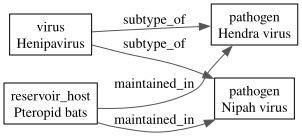

In [22]:
SUBGRAPH_NODE_COUNT = 4
SUBGRAPH_SEED = None
NARRATIVE_WORDS = 100
SUBGRAPH_OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'nipah_random_subgraph.svg'
NARRATIVE_PROMPT_PATH = ASSETS_ROOT / 'prompts' / 'subgraph_narrative_prompt_template.yaml'
NARRATIVE_SNAPSHOT_PATH = PROJECT_ROOT / 'outputs' / 'prompts' / 'subgraph-narrator-0.1.0.yaml'

sampled_subgraph = sample_random_connected_subgraph(
    result.typed_graph,
    num_nodes=SUBGRAPH_NODE_COUNT,
    seed=SUBGRAPH_SEED,
)
validate_ontology_labeled_graph(sampled_subgraph)
render_graph(
    sampled_subgraph,
    SUBGRAPH_OUTPUT_PATH,
    graph_name='NipahRandomSubgraph',
    require_ontology_labels=True,
)
display(SVG(filename=str(SUBGRAPH_OUTPUT_PATH)))

In [23]:

narrator_prompt = SubgraphNarrativePrompt.from_yaml_file(NARRATIVE_PROMPT_PATH)
narrator = SubgraphNarrator.from_graphicalizer(
    graphicalizer,
    prompt=narrator_prompt,
    prompt_snapshot_path=NARRATIVE_SNAPSHOT_PATH,
)
narrative = narrator.narrate(
    sampled_subgraph,
    SubgraphNarrativeConfig(target_words=NARRATIVE_WORDS),
)
print(textwrap.fill(narrative.narrative, width=NARRATIVE_COLUMNS))
print('Requested words:', narrative.requested_words)
print('Actual words:', narrative.actual_words)
if narrative.uncertainty:
    print('Uncertainty:', narrative.uncertainty)


The genus **Henipavirus**, encompassing **Hendra virus** and **Nipah virus**, is
recognized for its significant pathogenicity in humans, both diseases linked to
severe health outcomes and zoonotic potential. **Hendra virus**, maintained in
**Pteropid bats**, circulates within these bat populations and is transmitted to
humans, primarily through direct contact or intermediate hosts such as horses.
Similarly, **Nipah virus** thrives in the same bat reservoir, amplifying risks
to human health. This close association highlights the critical role of
**Pteropid bats** as natural reservoirs that facilitate the transmission of
these deadly viruses to amplifying hosts and humans, underscoring the need for
heightened surveillance and understanding of zoonotic spillover dynamics.
Requested words: 100
Actual words: 105


## Inspect node contexts

In [26]:
for node_context in result.node_contexts:
    print(f'\n[{node_context.entity_id}] {textwrap.fill(node_context.summary, width=NARRATIVE_COLUMNS)}')
    for evidence in node_context.evidence:
        print(f'  evidence: {textwrap.fill(evidence, width=NARRATIVE_COLUMNS)}')
    if node_context.uncertainty:
        print(f'  uncertainty: {textwrap.fill(node_context.uncertainty, width=NARRATIVE_COLUMNS)}')


[e1] Henipavirus encompasses Hendra and Nipah viruses, both known to cause severe
human diseases. These viruses can be transmitted from bats to amplifying hosts
like horses and pigs, or directly to humans, emphasizing the need for
understanding transmission routes.
  evidence: Hendra and Nipah virus are two henipaviruses known to cause severe disease in
humans.
  evidence: ...the virus can be transmitted directly to humans.

[e2] Hendra virus is a subtype of henipavirus that infects humans and can be
transmitted from bats. It is maintained in Pteropid bats, which are its natural
reservoir.
  evidence: Hendra and Nipah virus are two henipaviruses known to cause severe disease in
humans.
  evidence: Pteropid spp. bats are the natural reservoir of Hendra and Nipah virus.

[e3] Nipah virus, another subtype of henipavirus, is capable of infecting humans and
is also maintained in Pteropid bats, highlighting its zoonotic potential.
  evidence: Hendra and Nipah virus are two henipaviruses kno